# Cluster Centroid Drift Analysis
Tests whether the HDBSCAN model's cluster centroids have drifted when evaluated against the new 10-day log dataset.

**Method:**
1. Parse new log → 5-min windows → build feature matrix (same pipeline as production)
2. Assign clusters via cosine NN (same as `run_batch.py`)
3. Compute per-cluster centroids for train and new data (mean of member vectors in feature space)
4. Drift score = cosine distance between train centroid and test centroid per cluster
5. Visualise: drift scores, cluster distribution shift, UMAP overlay

In [2]:
import sys, os

# GCP pipeline dir has a trailing space in the folder name
gcp_dir = os.path.join(os.getcwd(), 'GCP-VM-Pipeline ')
if gcp_dir not in sys.path:
    sys.path.insert(0, gcp_dir)

import joblib
import numpy as np
import pandas as pd
from scipy.sparse import issparse
from sklearn.metrics.pairwise import cosine_distances
import matplotlib.pyplot as plt
import seaborn as sns

from pipeline import parse_nginx_lines, make_5min_windows, build_X

print('Imports OK')

Imports OK


In [3]:
ART = 'Trained-model Artifacts'

tfidf        = joblib.load(os.path.join(ART, 'tfidf.joblib'))
scaler       = joblib.load(os.path.join(ART, 'scaler.joblib'))
num_cols     = joblib.load(os.path.join(ART, 'num_cols.joblib'))
X_train      = joblib.load(os.path.join(ART, 'X_train.joblib'))
labels_train = joblib.load(os.path.join(ART, 'labels_train.joblib'))
nn_index     = joblib.load(os.path.join(ART, 'nn_index.joblib'))

print(f'X_train shape:       {X_train.shape}')
print(f'Training windows:    {len(labels_train)}')
print(f'Unique train clusters: {sorted(set(labels_train))}')

X_train shape:       (431, 511)
Training windows:    431
Unique train clusters: [np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13)]


## 1. Parse new log and build feature windows

In [4]:
LOG_PATH = 'access_last10days(BunnyCDN).log'

with open(LOG_PATH, 'r', encoding='utf-8', errors='ignore') as f:
    lines = f.readlines()

print(f'Total log lines: {len(lines):,}')

df_new = parse_nginx_lines(lines)
print(f'Parsed rows:     {len(df_new):,}')
print(f'Date range:      {df_new["Timestamp"].min()} → {df_new["Timestamp"].max()}')
df_new.head()

Total log lines: 25,643


Parsed rows:     25,643
Date range:      2026-02-24 00:06:33+00:00 → 2026-02-28 23:44:04+00:00


,client_ip,Timestamp,HTTP Status Code,Response size (bytes),http_method,http_path,User-Agent
0,205.210.31.19,2026-02-24 00:06:33+00:00,301,169,GET,/,"Hello from Palo Alto Networks, find out more a..."
1,205.210.31.19,2026-02-24 00:06:33+00:00,200,776,GET,/,"Hello from Palo Alto Networks, find out more a..."
2,87.120.191.67,2026-02-24 00:30:01+00:00,405,157,POST,/,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...
3,144.172.102.147,2026-02-24 00:36:50+00:00,301,169,GET,/.env.dev,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...
4,87.120.191.67,2026-02-24 00:38:00+00:00,301,169,POST,/,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...


In [5]:
windows_new = make_5min_windows(df_new)
print(f'5-min windows: {len(windows_new):,}')

# Check all required numeric columns are present
missing = [c for c in num_cols if c not in windows_new.columns]
if missing:
    print(f'WARNING - missing columns, will fill with 0: {missing}')
    for c in missing:
        windows_new[c] = 0

windows_new.head(3)

5-min windows: 1,069


,client_ip,window_start,request_count,unique_paths,unique_methods,status_200,status_401,status_403,status_404,status_429,status_500,avg_response_size,std_response_size,paths,uas,ratio_4xx,ratio_429,ratio_5xx,path_text
0,1.24.16.50,2026-02-28 10:15:00+00:00,1,1,1,1,0,0,0,0,0,1708.0,0.0,[/],[Mozilla/5.0 (Windows NT 6.1) AppleWebKit/537....,0.0,0.0,0.0,/
1,1.252.194.4,2026-02-28 20:30:00+00:00,1,1,1,0,0,0,0,0,0,169.0,0.0,[/],[-],0.0,0.0,0.0,/
2,1.55.210.222,2026-02-24 23:30:00+00:00,1,1,1,0,0,0,0,0,0,157.0,0.0,[/cgi-bin/.%0e/.%0e/.%0e/.%0e/.%0e/.%0e/.%0e/....,[-],0.0,0.0,0.0,/cgi-bin/.%0e/.%0e/.%0e/.%0e/.%0e/.%0e/.%0e/.%...


In [6]:
X_new = build_X(windows_new, tfidf, scaler, num_cols)
print(f'X_new shape: {X_new.shape}')

X_new shape: (1069, 511)


## 2. Assign clusters to new data (cosine NN — same as production)

In [7]:
PERCENTILE_THRESHOLD = 85  # same as run_batch.py

dist, idx = nn_index.kneighbors(X_new, n_neighbors=1, return_distance=True)
dist = dist.ravel()
idx  = idx.ravel()

assigned = labels_train[idx].copy()
dist_threshold = np.percentile(dist, PERCENTILE_THRESHOLD)
labels_new = np.array([int(a) if d <= dist_threshold else -1
                       for a, d in zip(assigned, dist)])

windows_new = windows_new.copy()
windows_new['cluster']          = labels_new
windows_new['cluster_strength'] = 1.0 - dist

counts_new = pd.Series(labels_new).value_counts().sort_index()
total_new  = len(labels_new)
noise_rate = (labels_new == -1).sum() / total_new

print(f'Total new windows : {total_new}')
print(f'Noise rate        : {noise_rate:.1%}')
print('\nCluster distribution (new data):')
print(counts_new)

Total new windows : 1069
Noise rate        : 33.1%

Cluster distribution (new data):
-1     354
 0       3
 1       1
 2       2
 3       3
 4     415
 5       3
 9     142
 10      3
 11    135
 13      8
Name: count, dtype: int64


## 3. Compute per-cluster centroids

In [8]:
def cluster_centroids(X, labels):
    """Return dict {cluster_id: mean_vector} for all non-noise clusters."""
    centroids = {}
    for lbl in sorted(set(labels)):
        if lbl == -1:
            continue
        mask = np.array(labels) == lbl
        Xc = X[mask]
        if issparse(Xc):
            centroids[lbl] = np.asarray(Xc.mean(axis=0)).ravel()
        else:
            centroids[lbl] = Xc.mean(axis=0)
    return centroids

centroids_train = cluster_centroids(X_train, labels_train)
centroids_new   = cluster_centroids(X_new,   labels_new)

print(f'Train clusters with centroids: {sorted(centroids_train.keys())}')
print(f'New   clusters with centroids: {sorted(centroids_new.keys())}')

Train clusters with centroids: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13)]
New   clusters with centroids: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(9), np.int64(10), np.int64(11), np.int64(13)]


## 4. Drift scores

In [9]:
CLUSTER_LABELS = {
    -1: 'WP exploit / noise',
     0: '.env harvesting',
     1: 'WP exploit',
     2: 'IoT login scan',
     3: '.env harvesting',
     4: 'Generic login',
     5: 'Generic login',
     6: 'Generic login',
     7: 'Swagger enum',
     8: 'WP exploit',
     9: 'WP exploit',
    10: 'Generic login',
    11: 'PHPUnit RCE',
    12: 'WP exploit',
    13: 'WP exploit',
}

drift_rows = []

# Add noise cluster (-1) first — no centroid drift computed for noise
drift_rows.append({
    'cluster':     -1,
    'label':       CLUSTER_LABELS[-1],
    'train_n':     int((np.array(labels_train) == -1).sum()),
    'new_n':       int((labels_new == -1).sum()),
    'drift_score': None,
})

for lbl in sorted(centroids_train.keys()):
    train_n = int((np.array(labels_train) == lbl).sum())
    new_n   = int((labels_new == lbl).sum())

    if lbl in centroids_new:
        tc = centroids_train[lbl].reshape(1, -1)
        nc = centroids_new[lbl].reshape(1, -1)
        drift = float(cosine_distances(tc, nc)[0, 0])
    else:
        drift = None  # cluster absent from new data

    drift_rows.append({
        'cluster':       lbl,
        'label':         CLUSTER_LABELS.get(lbl, '?'),
        'train_n':       train_n,
        'new_n':         new_n,
        'drift_score':   drift,
    })

drift_df = pd.DataFrame(drift_rows)
drift_df['drift_score'] = drift_df['drift_score'].round(4)

# Flag absent clusters
drift_df['status'] = drift_df['drift_score'].apply(
    lambda s: 'absent' if s is None else ('HIGH' if s > 0.3 else ('MED' if s > 0.1 else 'LOW'))
)

print(drift_df.to_string(index=False))

 cluster              label  train_n  new_n  drift_score status
      -1 WP exploit / noise       92    354          NaN    LOW
       0    .env harvesting       37      3       0.0388    LOW
       1         WP exploit       19      1       0.1904    MED
       2     IoT login scan       18      2       0.0683    LOW
       3    .env harvesting       32      3       0.1561    MED
       4      Generic login       14    415       0.1512    MED
       5      Generic login       17      3       0.0731    LOW
       6      Generic login       37      0          NaN    LOW
       7       Swagger enum       35      0          NaN    LOW
       8         WP exploit       21      0          NaN    LOW
       9         WP exploit       22    142       0.0192    LOW
      10      Generic login       15      3       0.2563    MED
      11        PHPUnit RCE       25    135       0.2377    MED
      12         WP exploit       20      0          NaN    LOW
      13         WP exploit       27    

## 5. Visualisations

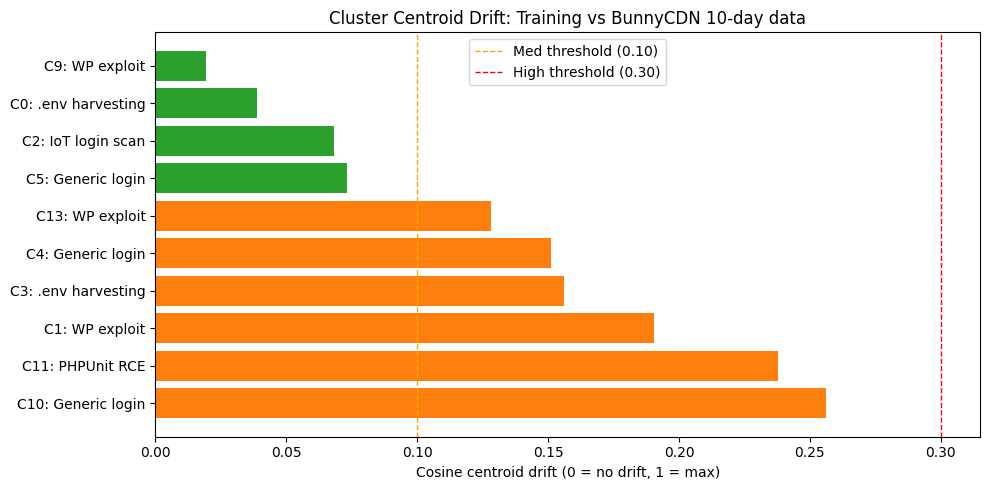


Clusters absent from new data (no new windows assigned):
 cluster              label  train_n
      -1 WP exploit / noise       92
       6      Generic login       37
       7       Swagger enum       35
       8         WP exploit       21
      12         WP exploit       20


In [10]:
plot_df = drift_df.dropna(subset=['drift_score']).sort_values('drift_score', ascending=False)

colors = ['#d62728' if s > 0.3 else '#ff7f0e' if s > 0.1 else '#2ca02c'
          for s in plot_df['drift_score']]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(
    [f'C{r.cluster}: {r.label}' for _, r in plot_df.iterrows()],
    plot_df['drift_score'],
    color=colors
)
ax.axvline(0.1, color='orange', linestyle='--', linewidth=1, label='Med threshold (0.10)')
ax.axvline(0.3, color='red',    linestyle='--', linewidth=1, label='High threshold (0.30)')
ax.set_xlabel('Cosine centroid drift (0 = no drift, 1 = max)')
ax.set_title('Cluster Centroid Drift: Training vs BunnyCDN 10-day data')
ax.legend()
plt.tight_layout()
plt.show()

absent = drift_df[drift_df['drift_score'].isna()]
if not absent.empty:
    print('\nClusters absent from new data (no new windows assigned):')
    print(absent[['cluster', 'label', 'train_n']].to_string(index=False))

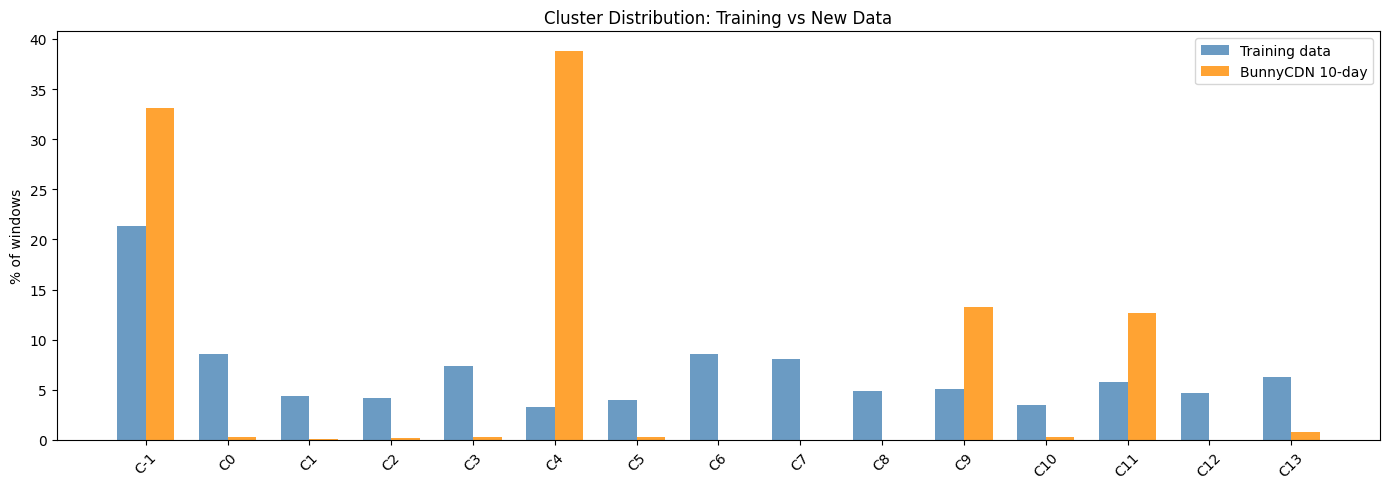

In [11]:
# Cluster distribution shift: % of windows per cluster
all_clusters = sorted(set(list(labels_train)) | set(list(labels_new)))

train_counts = pd.Series(labels_train).value_counts(normalize=True).reindex(all_clusters, fill_value=0)
new_counts   = pd.Series(labels_new).value_counts(normalize=True).reindex(all_clusters, fill_value=0)

x      = np.arange(len(all_clusters))
width  = 0.35
labels = [f'C{c}' for c in all_clusters]

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - width/2, train_counts.values * 100, width, label='Training data',    color='steelblue', alpha=0.8)
ax.bar(x + width/2, new_counts.values   * 100, width, label='BunnyCDN 10-day', color='darkorange', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45)
ax.set_ylabel('% of windows')
ax.set_title('Cluster Distribution: Training vs New Data')
ax.legend()
plt.tight_layout()
plt.show()

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(


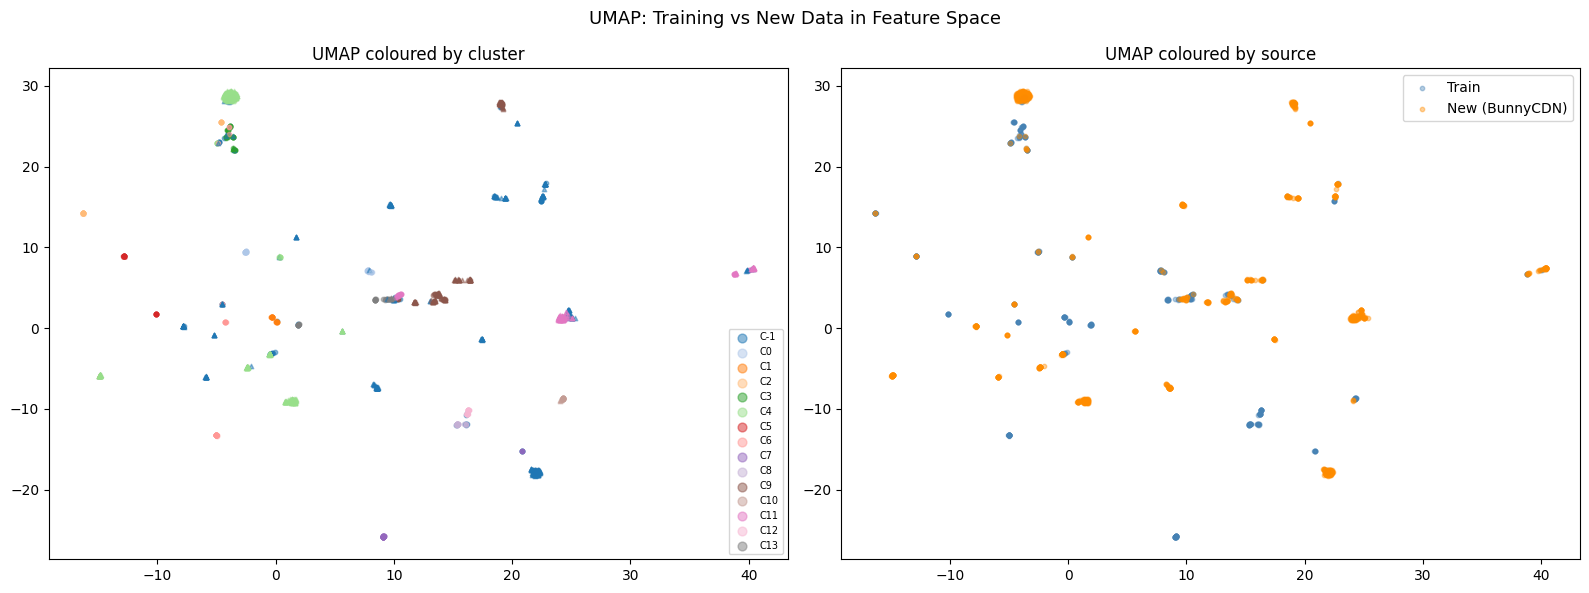

In [12]:
# UMAP overlay: training + new data coloured by cluster
# (can be slow on large matrices — sub-sample if needed)
import umap
from scipy.sparse import vstack

MAX_TRAIN = 500  # sub-sample training points for speed
MAX_NEW   = 2000

rng = np.random.default_rng(42)

train_idx = rng.choice(X_train.shape[0], size=min(MAX_TRAIN, X_train.shape[0]), replace=False)
new_idx   = rng.choice(X_new.shape[0],   size=min(MAX_NEW,   X_new.shape[0]),   replace=False)

X_combined      = vstack([X_train[train_idx], X_new[new_idx]])
labels_combined = np.concatenate([labels_train[train_idx], labels_new[new_idx]])
source_combined = ['train'] * len(train_idx) + ['new'] * len(new_idx)

reducer = umap.UMAP(n_components=2, metric='cosine', random_state=42, n_jobs=1)
embedding = reducer.fit_transform(X_combined)

umap_df = pd.DataFrame({
    'x':       embedding[:, 0],
    'y':       embedding[:, 1],
    'cluster': labels_combined,
    'source':  source_combined,
})

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: coloured by cluster
unique_clusters = sorted(umap_df['cluster'].unique())
palette = sns.color_palette('tab20', len(unique_clusters))
cmap = dict(zip(unique_clusters, palette))

for src, marker, ax_title in [('train', 'o', 'Training data'), ('new', '^', 'New BunnyCDN data')]:
    sub = umap_df[umap_df['source'] == src]
    for c in unique_clusters:
        pts = sub[sub['cluster'] == c]
        axes[0].scatter(pts['x'], pts['y'], s=10, alpha=0.5,
                        color=cmap[c], marker=marker,
                        label=f'C{c}' if src == 'train' else '_')

axes[0].set_title('UMAP coloured by cluster')
axes[0].legend(fontsize=7, markerscale=2, loc='best')

# Right: coloured by source (train vs new)
for src, color, label in [('train', 'steelblue', 'Train'), ('new', 'darkorange', 'New (BunnyCDN)')]:
    sub = umap_df[umap_df['source'] == src]
    axes[1].scatter(sub['x'], sub['y'], s=10, alpha=0.4, color=color, label=label)

axes[1].set_title('UMAP coloured by source')
axes[1].legend()

plt.suptitle('UMAP: Training vs New Data in Feature Space', fontsize=13)
plt.tight_layout()
plt.show()

## 6. Summary

In [13]:
print('='*60)
print('DRIFT SUMMARY')
print('='*60)
print(f'Training windows : {len(labels_train)}')
print(f'New windows      : {total_new}')
print(f'New noise rate   : {noise_rate:.1%}  (train: {(np.array(labels_train)==-1).sum()/len(labels_train):.1%})')
print()

high_drift = drift_df[drift_df['status'] == 'HIGH']
absent     = drift_df[drift_df['status'] == 'absent']

if not high_drift.empty:
    print('HIGH DRIFT clusters (cosine > 0.30) — attack pattern has evolved:')
    print(high_drift[['cluster', 'label', 'drift_score', 'train_n', 'new_n']].to_string(index=False))
    print()

if not absent.empty:
    print('ABSENT clusters — no new traffic matched these attack types:')
    print(absent[['cluster', 'label', 'train_n']].to_string(index=False))
    print()

low_drift = drift_df[drift_df['status'] == 'LOW']
print(f'LOW DRIFT clusters (stable, cosine < 0.10): {sorted(low_drift["cluster"].tolist())}')
print()
print('Full table:')
print(drift_df.sort_values('drift_score', ascending=False).to_string(index=False))

DRIFT SUMMARY
Training windows : 431
New windows      : 1069
New noise rate   : 33.1%  (train: 21.3%)

LOW DRIFT clusters (stable, cosine < 0.10): [-1, 0, 2, 5, 6, 7, 8, 9, 12]

Full table:
 cluster              label  train_n  new_n  drift_score status
      10      Generic login       15      3       0.2563    MED
      11        PHPUnit RCE       25    135       0.2377    MED
       1         WP exploit       19      1       0.1904    MED
       3    .env harvesting       32      3       0.1561    MED
       4      Generic login       14    415       0.1512    MED
      13         WP exploit       27      8       0.1282    MED
       5      Generic login       17      3       0.0731    LOW
       2     IoT login scan       18      2       0.0683    LOW
       0    .env harvesting       37      3       0.0388    LOW
       9         WP exploit       22    142       0.0192    LOW
      -1 WP exploit / noise       92    354          NaN    LOW
       6      Generic login       37      